# start final project

In [1]:
import pandas as pd

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

df = pd.read_csv(URL, header=0)

df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


### identifying missing values and relacing them with the mean of the column

In [2]:
missingcols=[]
a=df.columns[df.isnull().any()]
missingcols.append(a)
a

Index(['tax'], dtype='object')

In [3]:
print(df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

print(df.isnull().sum())

model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             3
mpg             0
engineSize      0
price           0
dtype: int64
model           0
year            0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
price           0
dtype: int64


In [4]:
remaining = df.isnull().sum().sum()
print("Remaining missing values after replacement:", remaining)
print("All missing values replaced:", remaining == 0)

Remaining missing values after replacement: 0
All missing values replaced: True


### find and removing duplicate values 

In [5]:
duplicate_rows = [df[df.duplicated(keep=False)]]
print(duplicate_rows)

[           model  year transmission  mileage fuelType    tax   mpg  \
25         Focus  2017       Manual    13063   Petrol  145.0  41.5   
27        Fiesta  2015       Manual    25935   Petrol    0.0  65.7   
28        Fiesta  2018       Manual     8700   Petrol  145.0  58.9   
113        Focus  2016       Manual    30923   Diesel    0.0  74.3   
159        Focus  2016       Manual    30923   Diesel    0.0  74.3   
...          ...   ...          ...      ...      ...    ...   ...   
15127   EcoSport  2019    Automatic      433   Petrol  150.0  45.6   
15684         KA  2008       Manual    63000   Petrol  160.0  45.6   
15685         KA  2008       Manual    63000   Petrol  160.0  45.6   
17607      B-MAX  2017    Automatic     5000   Petrol  145.0  44.1   
17608      B-MAX  2017    Automatic     5000   Petrol  145.0  44.1   

       engineSize  price  
25            2.0  18499  
27            1.0   8299  
28            1.0  12499  
113           1.5  10995  
159           1.5  1099

In [6]:
dup_mask = df.duplicated()
dup_count = int(dup_mask.sum())
print("Duplicate rows found:", dup_count)

Duplicate rows found: 154


In [7]:
df = df.drop_duplicates()
print("Duplicates removed. New row count:", df.shape[0])

Duplicates removed. New row count: 17812


### exploratory data analysis

In [8]:
corr = df.corr(numeric_only=True)
price_corr = corr['price'].drop('price')
top5_features = price_corr.abs().sort_values(ascending=False).head(5).index
print("Top 5 attributes by correlation with price (with sign):")
for feat in top5_features:
    print(feat, price_corr[feat])

Top 5 attributes by correlation with price (with sign):
year 0.6357149468587046
mileage -0.5304825270168149
engineSize 0.41145110277015723
tax 0.40596994143274995
mpg -0.3462629383809921


In [9]:
df['fuelType'].value_counts()

fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64

### visual exploratory analysis

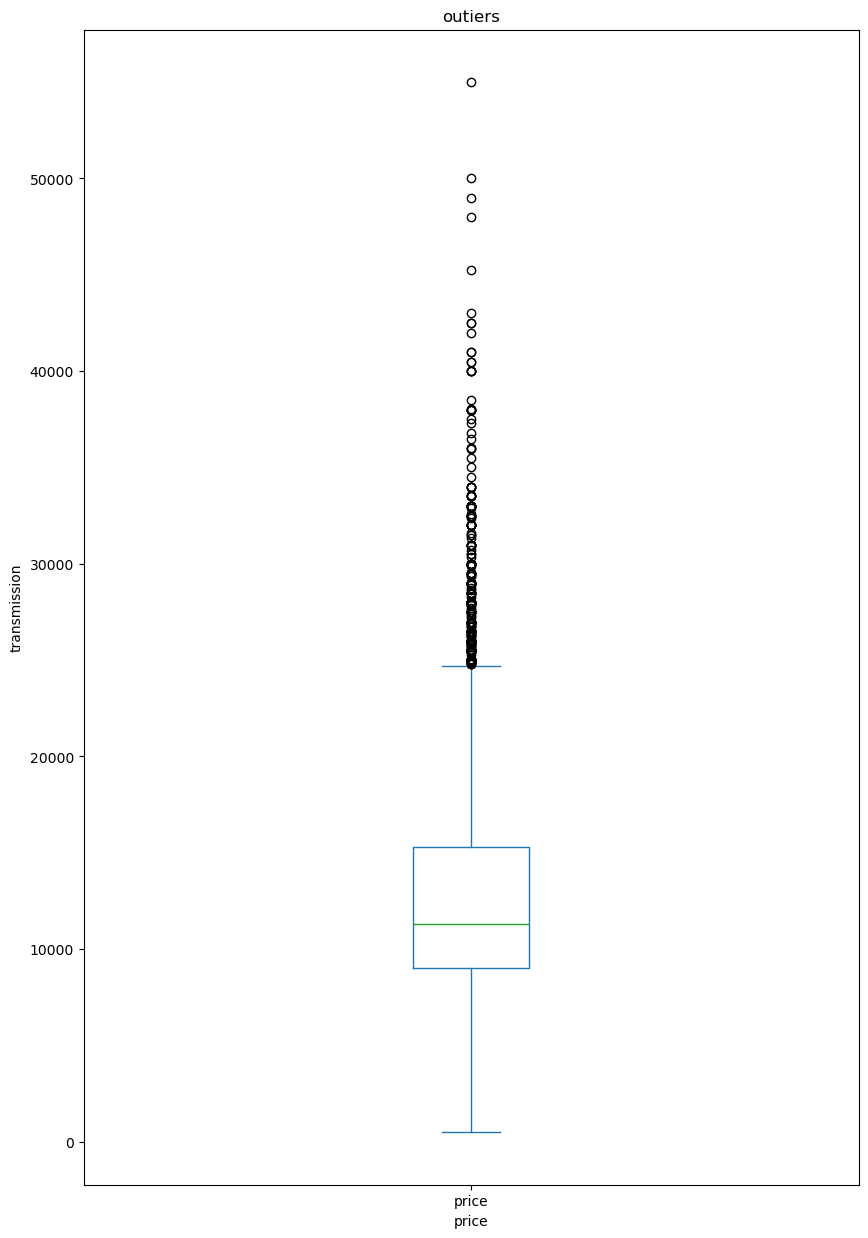

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
df.plot(kind="box",x="transmission", y="price", figsize=(10,15))
plt.title("outiers")
plt.xlabel("price")
plt.ylabel("transmission")
plt.show()

In [11]:
df.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize', 'price'],
      dtype='object')

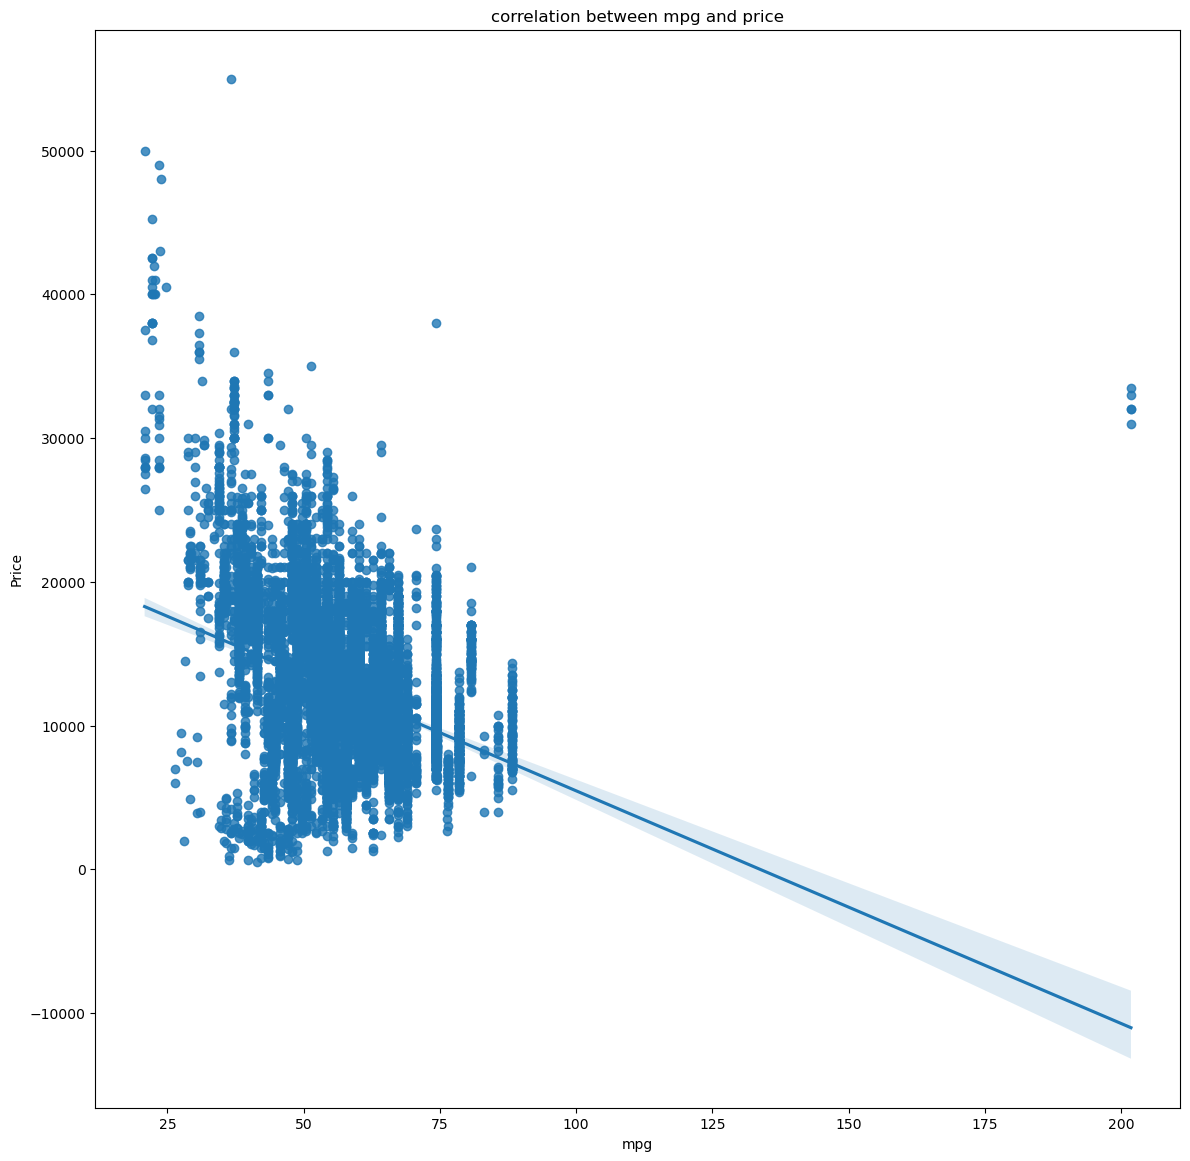

In [14]:
plt.figure(figsize=(14,14))
sns.regplot(data=df, x="mpg", y="price")
plt.title("correlation between mpg and price")
plt.xlabel("mpg")
plt.ylabel("Price")
plt.show()

## Model Development and Evaluation

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [17]:
source_col = 'mpg'
target_col = 'price'

X = df[[source_col]].values
y = df[target_col].values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("R^2:", r2)
print("MSE:", mse)

R^2: 0.1198980224962416
MSE: 19741690.809446193


In [18]:
features=['year', 'mileage', 'tax', 'mpg', 'engineSize']
X=df[features].values
y=df['price'].values

model=LinearRegression()
model.fit(X,y)

y_pred=model.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("R^2:", r2)
print("MSE:", mse)

R^2: 0.7265379654547051
MSE: 6134065.224381628


### Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [27]:
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features].values
y = df['price'].values

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

pipe.fit(X, y)
y_pred = pipe.predict(X)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("R^2:", r2)
print("MSE:", mse)

R^2: 0.7666619695239302
MSE: 5234038.06546274


### Ridge Regression

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

In [30]:
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
x = df[features].values
y = df['price'].values
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=1)
ridge_model=Ridge(alpha=0.1)
ridge_model.fit(x_train, y_train)
r2=ridge_model.score(x_test, y_test)
print("R2 score=", r2)

R2 score= 0.7252697595945741


### fitting a polynomial of degree 2

In [39]:
# Polynomial transform (degree = 2)
pr = PolynomialFeatures(degree=2)

X_train_poly = pr.fit_transform(x_train)
X_test_poly = pr.transform(x_test)

# Ridge Regression
ridge_model = Ridge(alpha=0.1)

# Fit model
ridge_model.fit(X_train_poly, y_train)

# Predictions
y_pred = ridge_model.predict(X_test_poly)

# Evaluation
r2 = r2_score(y_test, y_pred)
print("R2 score=", r2)

R2 score= 0.7682778306409357


C:\Users\taiba\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.257e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


### Grid search 

In [37]:
from sklearn.model_selection import GridSearchCV
parameters={'alpha': [0.01, 0.1, 1, 10, 100]}
RR= Ridge()
model_cv=GridSearchCV(estimator=RR, param_grid=parameters, cv=4)
model_cv.fit(x_train, y_train)
print("Best alpha:", model_cv.best_params_['alpha'])

# Best cross-validation score
print("Best CV score:", model_cv.best_score_)

Best alpha: 10
Best CV score: 0.7245136589326866


### Ridge model using polynomial degree 3 and best alpha 10

In [40]:
pr = PolynomialFeatures(degree=3)

X_train_poly = pr.fit_transform(x_train)
X_test_poly = pr.transform(x_test)

# Ridge Regression
ridge_model = Ridge(alpha=10)

# Fit model
ridge_model.fit(X_train_poly, y_train)

# Predictions
y_pred = ridge_model.predict(X_test_poly)

# Evaluation
r2 = r2_score(y_test, y_pred)
print("R2 score=", r2)

R2 score= 0.8075430070040386


C:\Users\taiba\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.92543e-32): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
